<a href="https://colab.research.google.com/github/priymakandrey-toothless/IAD_lab/blob/main/IAD_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Налаштування стилю графіків
sns.set_theme(style="whitegrid", palette="muted")

# 1. Завантаження датасету
df = pd.read_csv('Obfuscated-MalMem2022.csv')

# 2. Розмір датасету та назви колонок
print(f"Розмір датасету: {df.shape[0]} рядків, {df.shape[1]} колонок\n")
print("Назви колонок:")
print(df.columns.tolist())

# 3. Перевірка типів даних
print("\nРозподіл типів даних:")
print(df.dtypes.value_counts())
print("\nНечислові (object) колонки:", df.select_dtypes(include=['object']).columns.tolist())

# 4. Розподіл об'єктів за класами
print("\nРозподіл цільової змінної 'Class' (Бінарна класифікація):")
print(df['Class'].value_counts())

# Додатково перевіримо основні сімейства з колонки 'Category'
df['Malware_Family'] = df['Category'].apply(lambda x: x.split('-')[0])
print("\nРозподіл за сімействами у 'Category':")
print(df['Malware_Family'].value_counts())

# Видаляємо допоміжну колонку перед подальшою обробкою
df.drop(columns=['Malware_Family'], inplace=True)

Розмір датасету: 58596 рядків, 57 колонок

Назви колонок:
['Category', 'pslist.nproc', 'pslist.nppid', 'pslist.avg_threads', 'pslist.nprocs64bit', 'pslist.avg_handlers', 'dlllist.ndlls', 'dlllist.avg_dlls_per_proc', 'handles.nhandles', 'handles.avg_handles_per_proc', 'handles.nport', 'handles.nfile', 'handles.nevent', 'handles.ndesktop', 'handles.nkey', 'handles.nthread', 'handles.ndirectory', 'handles.nsemaphore', 'handles.ntimer', 'handles.nsection', 'handles.nmutant', 'ldrmodules.not_in_load', 'ldrmodules.not_in_init', 'ldrmodules.not_in_mem', 'ldrmodules.not_in_load_avg', 'ldrmodules.not_in_init_avg', 'ldrmodules.not_in_mem_avg', 'malfind.ninjections', 'malfind.commitCharge', 'malfind.protection', 'malfind.uniqueInjections', 'psxview.not_in_pslist', 'psxview.not_in_eprocess_pool', 'psxview.not_in_ethread_pool', 'psxview.not_in_pspcid_list', 'psxview.not_in_csrss_handles', 'psxview.not_in_session', 'psxview.not_in_deskthrd', 'psxview.not_in_pslist_false_avg', 'psxview.not_in_eproces

In [ ]:
from sklearn.preprocessing import LabelEncoder

# 1. Перевірка пропущених значень
missing_count = df.isnull().sum().sum()
print(f"Загальна кількість пропущених значень (NaN): {missing_count}")

# 2. Перевірка та видалення дублікатів
dup_count = df.duplicated().sum()
print(f"Кількість дублікатів рядків: {dup_count}")
df_clean = df.drop_duplicates().copy()
print(f"Розмір після видалення дублікатів: {df_clean.shape}")

# 3. Пошук та видалення константних колонок (де лише 1 унікальне значення)
const_cols = [col for col in df_clean.columns if df_clean[col].nunique() <= 1]
print(f"Константні ознаки з нульовою дисперсією: {const_cols}")

# 4. Кодування цільової змінної та формування X і y
le = LabelEncoder()
df_clean['Class_Encoded'] = le.fit_transform(df_clean['Class'])
print("\nКодування класів:", dict(zip(le.classes_, le.transform(le.classes_))))

# Видаляємо 'Category', текстовий 'Class' та константні ознаки
X = df_clean.drop(columns=['Category', 'Class', 'Class_Encoded'] + const_cols)
y = df_clean['Class_Encoded']

print(f"\nФінальна матриця ознак X: {X.shape}")
print(f"Вектор цільової змінної y: {y.shape}")

Загальна кількість пропущених значень (NaN): 0
Кількість дублікатів рядків: 534
Розмір після видалення дублікатів: (58062, 57)
Константні ознаки з нульовою дисперсією: ['pslist.nprocs64bit', 'handles.nport', 'svcscan.interactive_process_services']

Кодування класів: {'Benign': np.int64(0), 'Malware': np.int64(1)}

Фінальна матриця ознак X: (58062, 52)
Вектор цільової змінної y: (58062,)


Топ-10 ознак за абсолютною кореляцією з цільовою змінною:
dlllist.avg_dlls_per_proc    0.9088
handles.nevent               0.8764
handles.nthread              0.8720
handles.nmutant              0.8545
dlllist.ndlls                0.8233
handles.nsection             0.8199
pslist.avg_threads           0.7909
ldrmodules.not_in_load       0.7865
ldrmodules.not_in_mem        0.7864
handles.ntimer               0.7829
dtype: float64


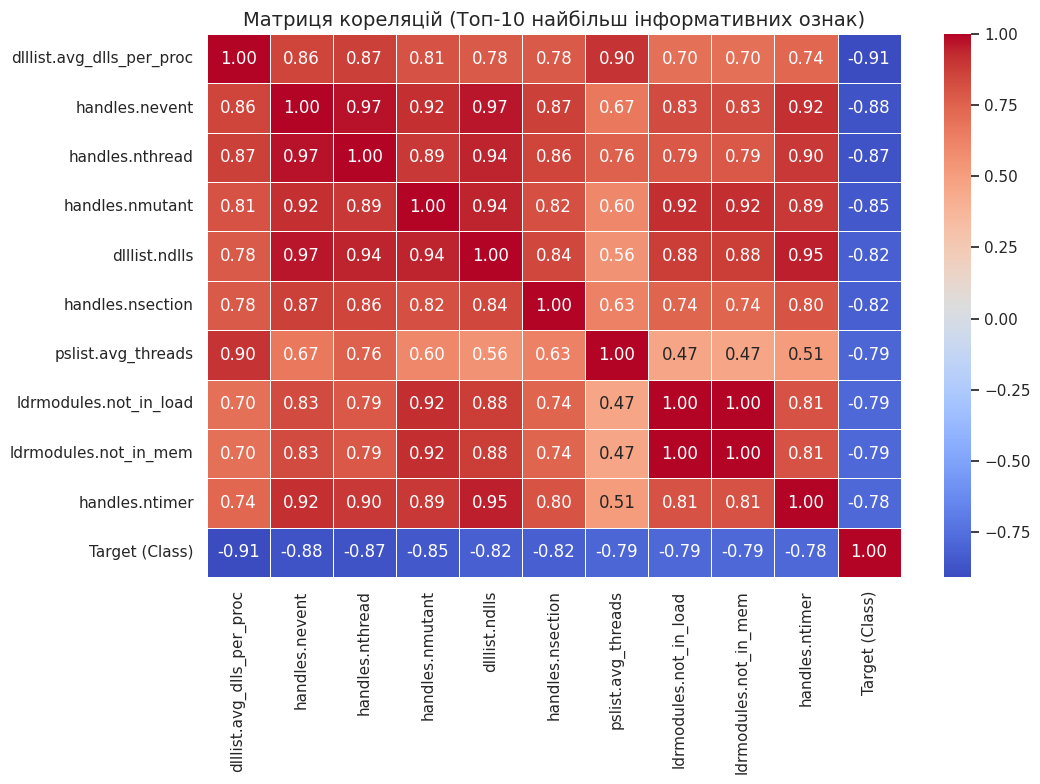

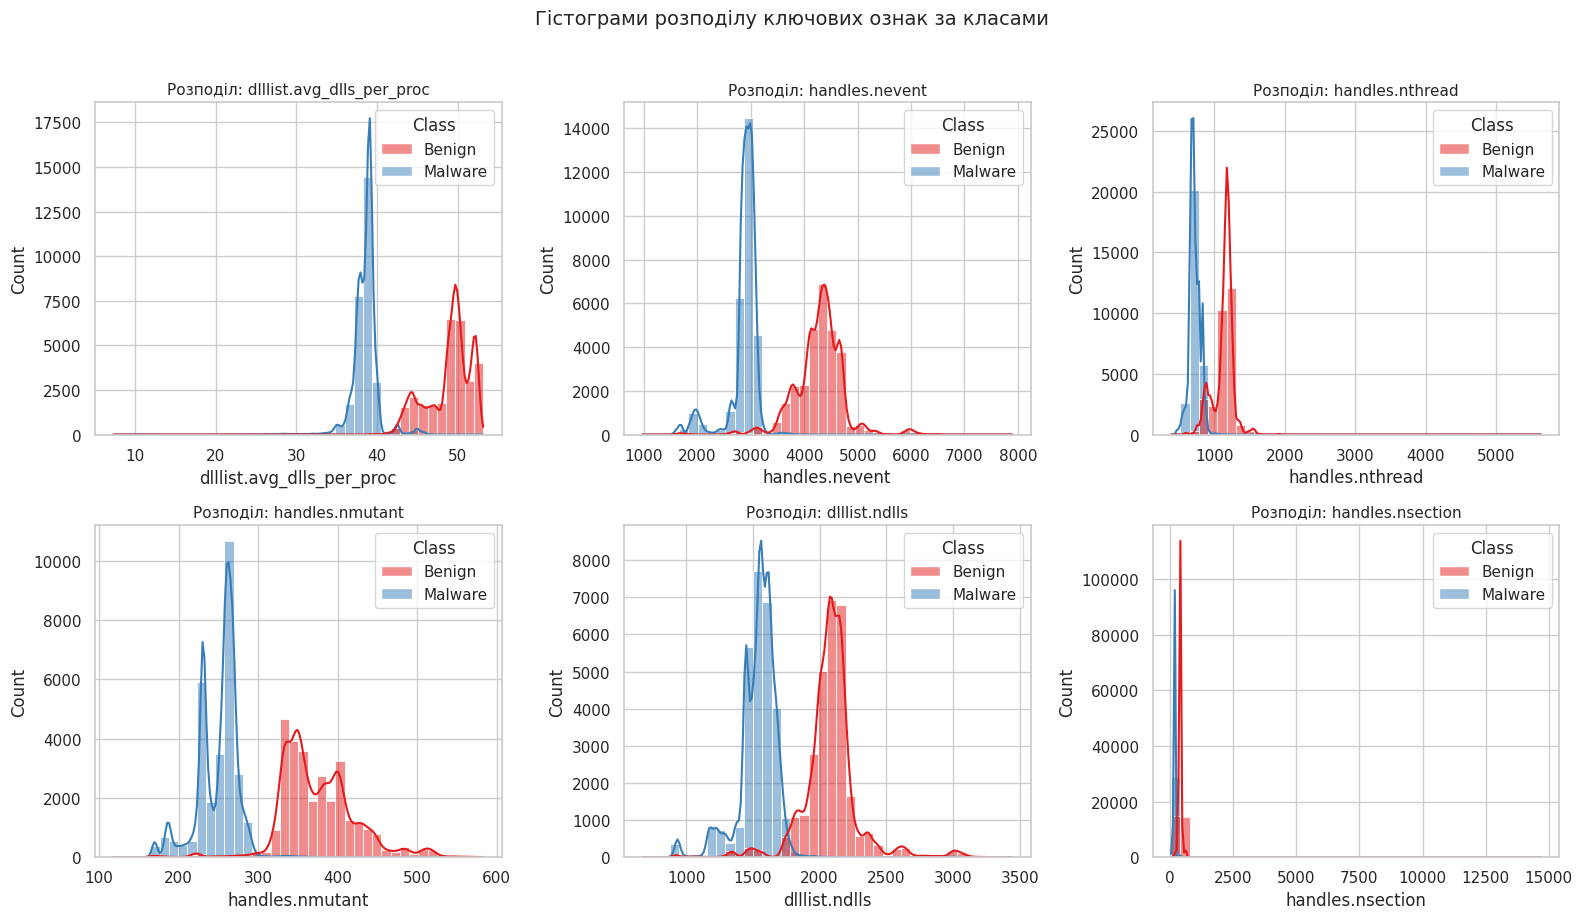

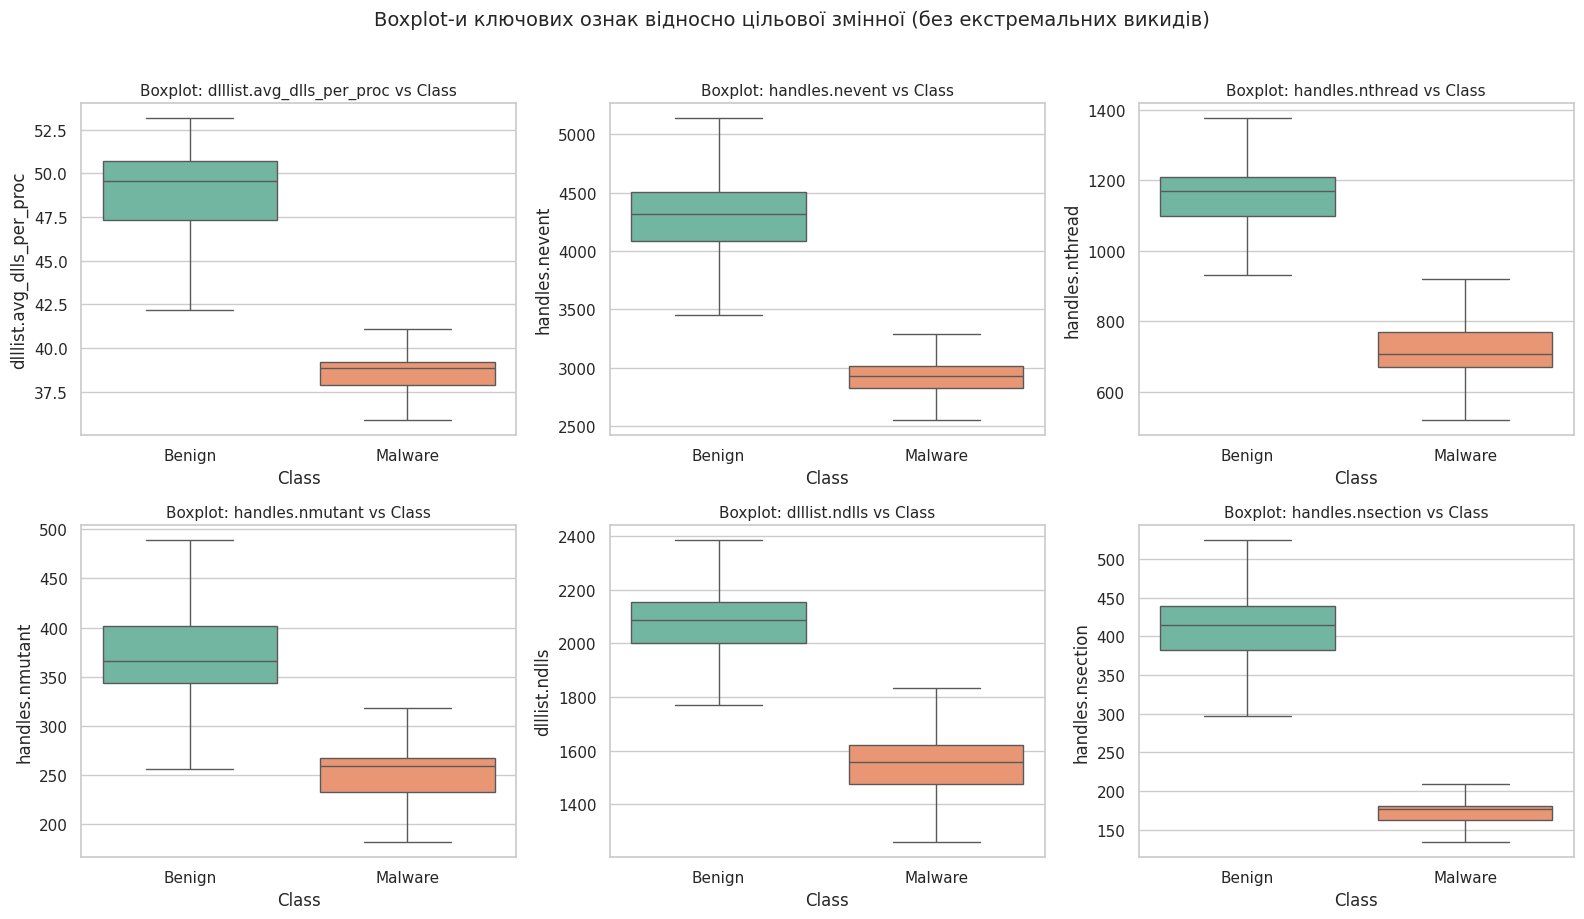

In [ ]:
# Обчислення кореляції всіх ознак із цільовою змінною
correlations = X.apply(lambda col: np.corrcoef(col, y)[0, 1]).abs().sort_values(ascending=False)
top_10_features = correlations.head(10).index.tolist()

print("Топ-10 ознак за абсолютною кореляцією з цільовою змінною:")
print(correlations.head(10).round(4))

# 1. Heatmap кореляцій для топ-10 ознак + Target
plt.figure(figsize=(11, 8))
corr_matrix = X[top_10_features].copy()
corr_matrix['Target (Class)'] = y
sns.heatmap(corr_matrix.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Матриця кореляцій (Топ-10 найбільш інформативних ознак)", fontsize=14)
plt.tight_layout()
plt.show()

# 2. Гістограми розподілу для топ-6 ознак з розбиттям за класами
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for i, col in enumerate(top_10_features[:6]):
    ax = axes[i // 3, i % 3]
    sns.histplot(data=df_clean, x=col, hue='Class', bins=40, kde=True, ax=ax, palette='Set1')
    ax.set_title(f"Розподіл: {col}", fontsize=11)
plt.suptitle("Гістограми розподілу ключових ознак за класами", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# 3. Boxplot-и топ-6 ознак відносно цільової змінної
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for i, col in enumerate(top_10_features[:6]):
    ax = axes[i // 3, i % 3]
    sns.boxplot(data=df_clean, x='Class', y=col, ax=ax, palette='Set2', showfliers=False)
    ax.set_title(f"Boxplot: {col} vs Class", fontsize=11)
plt.suptitle("Boxplot-и ключових ознак відносно цільової змінної (без екстремальних викидів)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Розділення на train (80%) та test (20%) вибірки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Розмір навчальної вибірки (Train): {X_train.shape[0]} об'єктів")
print(f"Розмір тестової вибірки (Test):  {X_test.shape[0]} об'єктів")

# 2. Масштабування ознак (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Розмір навчальної вибірки (Train): 46449 об'єктів
Розмір тестової вибірки (Test):  11613 об'єктів


In [ ]:
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Ініціалізація 5 моделей
models = {
    "kNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1),
    "AdaBoost": AdaBoostClassifier(random_state=42, algorithm='SAMME')
}

predictions = {}
training_times = {}

# Навчання та прогнозування
for name, model in models.items():
    start_time = time.time()
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    elapsed = time.time() - start_time

    predictions[name] = preds
    training_times[name] = elapsed
    acc = accuracy_score(y_test, preds)
    errors = (y_test != preds).sum()
    print(f"{name:15s} | Accuracy: {acc:.6f} | Помилок: {errors:2d} з {len(y_test)} | Час: {elapsed:.2f} с")

kNN             | Accuracy: 0.999742 | Помилок:  3 з 11613 | Час: 9.90 с
Decision Tree   | Accuracy: 1.000000 | Помилок:  0 з 11613 | Час: 0.49 с
SVM             | Accuracy: 0.999742 | Помилок:  3 з 11613 | Час: 2.96 с
Random Forest   | Accuracy: 1.000000 | Помилок:  0 з 11613 | Час: 7.00 с
AdaBoost        | Accuracy: 1.000000 | Помилок:  0 з 11613 | Час: 7.63 с


Підбір n_neighbors для kNN:
  k =  1 -> Test Accuracy = 0.999914
  k =  3 -> Test Accuracy = 0.999828
  k =  5 -> Test Accuracy = 0.999742
  k =  7 -> Test Accuracy = 0.999828
  k =  9 -> Test Accuracy = 0.999828
  k = 11 -> Test Accuracy = 0.999828
  k = 15 -> Test Accuracy = 0.999828

Оптимальне значення n_neighbors = 1 (Accuracy: 0.999914)


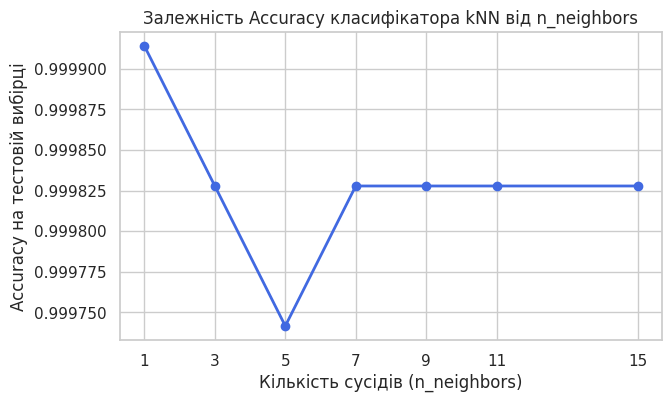


Запуск GridSearchCV для SVM...
Найкращі параметри SVM: {'C': 50, 'gamma': 0.01}
Найкращий CV Score: 0.999300
Test Accuracy для налаштованого SVM: 1.000000


In [ ]:
from sklearn.model_selection import GridSearchCV

# --- 1. Підбір оптимального n_neighbors для kNN ---
k_values = [1, 3, 5, 7, 9, 11, 15]
knn_scores = []

print("Підбір n_neighbors для kNN:")
for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn_temp.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, knn_temp.predict(X_test_scaled))
    knn_scores.append(acc)
    print(f"  k = {k:2d} -> Test Accuracy = {acc:.6f}")

best_k = k_values[np.argmax(knn_scores)]
print(f"\nОптимальне значення n_neighbors = {best_k} (Accuracy: {max(knn_scores):.6f})")

# Графік залежності точності kNN від k
plt.figure(figsize=(7, 4))
plt.plot(k_values, knn_scores, marker='o', linewidth=2, color='royalblue')
plt.title("Залежність Accuracy класифікатора kNN від n_neighbors")
plt.xlabel("Кількість сусідів (n_neighbors)")
plt.ylabel("Accuracy на тестовій вибірці")
plt.xticks(k_values)
plt.grid(True)
plt.show()

# Зберігаємо найкращу модель kNN
best_knn = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
best_knn.fit(X_train_scaled, y_train)
predictions["kNN (Tuned)"] = best_knn.predict(X_test_scaled)

# --- 2. Підбір C та gamma для SVM за допомогою GridSearchCV ---
# Формуємо стратифіковану підвибірку 10 000 записів з train для швидкого GridSearchCV
X_sub, _, y_sub, _ = train_test_split(
    X_train_scaled, y_train, train_size=10000, random_state=42, stratify=y_train
)

param_grid_svm = {
    'C': [0.1, 1, 10, 50],
    'gamma': ['scale', 0.001, 0.01, 0.1]
}

grid_svm = GridSearchCV(
    SVC(random_state=42),
    param_grid=param_grid_svm,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

print("\nЗапуск GridSearchCV для SVM...")
grid_svm.fit(X_sub, y_sub)
print(f"Найкращі параметри SVM: {grid_svm.best_params_}")
print(f"Найкращий CV Score: {grid_svm.best_score_:.6f}")

# Навчаємо фінальний SVM з найкращими параметрами на повній навчальній вибірці
best_svm = SVC(**grid_svm.best_params_, random_state=42)
best_svm.fit(X_train_scaled, y_train)
predictions["SVM (Tuned)"] = best_svm.predict(X_test_scaled)
print(f"Test Accuracy для налаштованого SVM: {accuracy_score(y_test, predictions['SVM (Tuned)']):.6f}")

МОДЕЛЬ: kNN
Confusion Matrix:
[[5846    1]
 [   2 5764]]

Classification Report:
              precision    recall  f1-score   support

  Benign (0)     0.9997    0.9998    0.9997      5847
 Malware (1)     0.9998    0.9997    0.9997      5766

    accuracy                         0.9997     11613
   macro avg     0.9997    0.9997    0.9997     11613
weighted avg     0.9997    0.9997    0.9997     11613

МОДЕЛЬ: Decision Tree
Confusion Matrix:
[[5847    0]
 [   0 5766]]

Classification Report:
              precision    recall  f1-score   support

  Benign (0)     1.0000    1.0000    1.0000      5847
 Malware (1)     1.0000    1.0000    1.0000      5766

    accuracy                         1.0000     11613
   macro avg     1.0000    1.0000    1.0000     11613
weighted avg     1.0000    1.0000    1.0000     11613

МОДЕЛЬ: SVM
Confusion Matrix:
[[5846    1]
 [   2 5764]]

Classification Report:
              precision    recall  f1-score   support

  Benign (0)     0.9997    0.9998    0

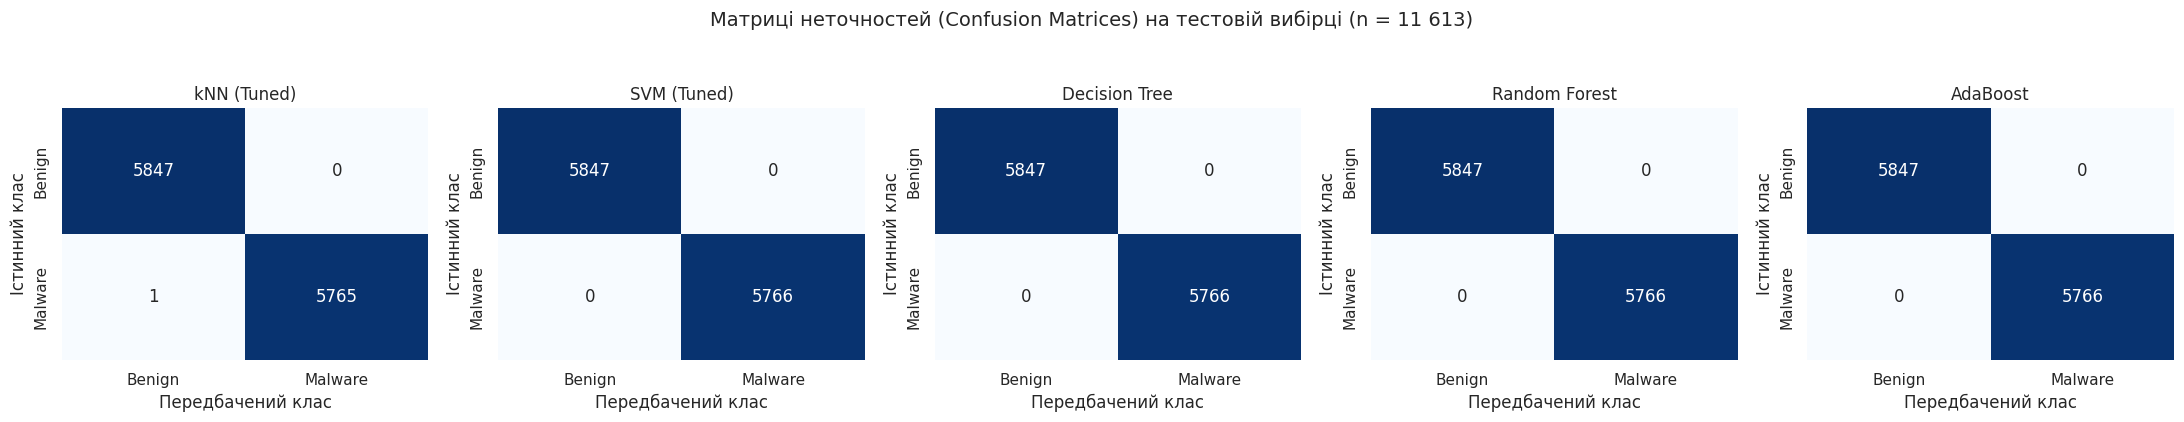

In [ ]:
# 1. Виведення Classification Report та Confusion Matrix для кожної моделі
for name, preds in predictions.items():
    print("=" * 65)
    print(f"МОДЕЛЬ: {name}")
    print("=" * 65)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, preds))
    print("\nClassification Report:")
    print(classification_report(y_test, preds, target_names=['Benign (0)', 'Malware (1)'], digits=4))

# 2. Візуалізація матриць неточностей (Confusion Matrices) для 5 основних моделей
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
base_models = ["kNN (Tuned)", "SVM (Tuned)", "Decision Tree", "Random Forest", "AdaBoost"]

for i, name in enumerate(base_models):
    cm = confusion_matrix(y_test, predictions[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[i],
                xticklabels=['Benign', 'Malware'], yticklabels=['Benign', 'Malware'])
    axes[i].set_title(name, fontsize=12)
    axes[i].set_xlabel('Передбачений клас')
    axes[i].set_ylabel('Істинний клас')

plt.suptitle("Матриці неточностей (Confusion Matrices) на тестовій вибірці (n = 11 613)", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()